# 14a: Statistical Analysis of Radiomics Features vs Rejection (Normalised Images)

Source data:
- Radiomics features: `reports/12_radiomics_features_normalised.csv` (from notebook 12 normalised)
- Clinical labels: `../data/bd_estudiUPF.csv` (original spreadsheet)

For each radiomics feature, test whether it differs between rejection and no-rejection groups.

Method:
1. Check normality (Shapiro-Wilk) to decide t-test vs Mann-Whitney
2. Run univariate tests without alpha correction first
3. If significant features found, apply Benjamini-Hochberg FDR correction
4. Stratify by time period (early vs late, per Clara's paper findings)
5. Compute feature correlation matrix

In [1]:
import pandas as pd
import numpy as np
from scipy import stats
from statsmodels.stats.multitest import multipletests
import matplotlib.pyplot as plt
import os

print("Imports OK")

Imports OK


In [2]:
# load radiomics features directly from normalised source CSV
radiomics = pd.read_csv(os.path.join("reports", "12_radiomics_features_normalised.csv"))
print(f"Radiomics (normalised): {radiomics.shape[0]} studies, {radiomics.shape[1]} columns")

# load clinical labels directly from source CSV
clinical = pd.read_csv(os.path.join("..", "data", "bd_estudiUPF.csv"))
clinical["id estudio"] = clinical["id estudio"].astype(str).str.strip()
print(f"Clinical: {clinical.shape[0]} rows")

# join: bring rejection label and motivo into radiomics table
motivo_col = "motivo (1: 1 semana, 2: 1 mes, 3: 1 año, 4: sospecha, 5: seguimiento)="
labels = clinical[["id estudio", motivo_col, "RECHAZO CLÍNICO"]].rename(columns={
    "id estudio": "study_id",
    motivo_col: "motivo",
    "RECHAZO CLÍNICO": "rejection",
})

df = pd.merge(radiomics, labels, on="study_id", how="inner")
print(f"Matched: {len(df)} rows")

feature_cols = [c for c in df.columns if c.startswith("original_")]
print(f"Radiomics feature columns: {len(feature_cols)}")

Radiomics (normalised): 137 studies, 94 columns
Clinical: 138 rows
Matched: 137 rows
Radiomics feature columns: 93


In [3]:
# group split
rejection = df[df["rejection"] == 1]
no_rejection = df[df["rejection"] == 0]

print(f"No rejection: {len(no_rejection)}")
print(f"Rejection: {len(rejection)}")

No rejection: 98
Rejection: 39


## Note on repeated measures

The 137 studies come from 55 patients (mean 2.5 studies per patient). Some patients
have up to 6 studies, and 14 patients have both rejection and no-rejection studies.

All statistical tests below treat each study as an independent observation. This is
the same approach used in Bassaganyas et al. 2025 and is standard for this type of
clinical imaging study. However, it is a known limitation: studies from the same
patient are not truly independent (they share genetics, surgical technique, baseline
organ characteristics), which can inflate the effective sample size.

A sensitivity analysis showed that results are sensitive to which study is selected
when restricting to one per patient (see `docs/PLAN_REPEATED_MEASURES.md` for
detailed investigation approaches). This should be acknowledged when interpreting
the p-values below.

## Normality check

In [4]:
normality_results = []

for feat in feature_cols:
    vals_no_rej = no_rejection[feat].dropna()
    vals_rej = rejection[feat].dropna()

    _, p_no_rej = stats.shapiro(vals_no_rej)
    _, p_rej = stats.shapiro(vals_rej)

    both_normal = (p_no_rej > 0.05) and (p_rej > 0.05)
    normality_results.append({
        "feature": feat,
        "shapiro_p_no_rej": p_no_rej,
        "shapiro_p_rej": p_rej,
        "both_normal": both_normal,
    })

norm_df = pd.DataFrame(normality_results)
n_normal = norm_df["both_normal"].sum()
print(f"Features passing normality in both groups: {n_normal}")
print(f"Features failing normality (will use Mann-Whitney): {len(norm_df) - n_normal}")

Features passing normality in both groups: 22
Features failing normality (will use Mann-Whitney): 71


## Univariate testing -- full dataset (uncorrected)

In [5]:
test_results = []

for i, feat in enumerate(feature_cols):
    vals_no_rej = no_rejection[feat].dropna().values
    vals_rej = rejection[feat].dropna().values

    is_normal = norm_df.loc[i, "both_normal"]

    if is_normal:
        stat, p_value = stats.ttest_ind(vals_no_rej, vals_rej, equal_var=False)
        test_name = "t-test"
        # cohen's d
        pooled_std = np.sqrt(
            ((len(vals_no_rej) - 1) * vals_no_rej.std(ddof=1)**2 +
             (len(vals_rej) - 1) * vals_rej.std(ddof=1)**2) /
            (len(vals_no_rej) + len(vals_rej) - 2)
        )
        if pooled_std > 0:
            effect_size = (vals_rej.mean() - vals_no_rej.mean()) / pooled_std
        else:
            effect_size = 0.0
    else:
        stat, p_value = stats.mannwhitneyu(vals_no_rej, vals_rej, alternative="two-sided")
        test_name = "Mann-Whitney"
        # rank-biserial correlation
        n1 = len(vals_no_rej)
        n2 = len(vals_rej)
        effect_size = 1 - (2 * stat) / (n1 * n2)

    test_results.append({
        "feature": feat,
        "test": test_name,
        "statistic": stat,
        "p_value": p_value,
        "effect_size": effect_size,
        "mean_no_rej": vals_no_rej.mean(),
        "mean_rej": vals_rej.mean(),
        "median_no_rej": np.median(vals_no_rej),
        "median_rej": np.median(vals_rej),
    })

results_df = pd.DataFrame(test_results)
results_df = results_df.sort_values("p_value").reset_index(drop=True)

print(f"Tests used: {results_df['test'].value_counts().to_dict()}")

Tests used: {'Mann-Whitney': 71, 't-test': 22}


In [6]:
# results
significant = results_df[results_df["p_value"] < 0.05]
print(f"Features with uncorrected p < 0.05: {len(significant)} out of {len(results_df)}")
print()

if len(significant) > 0:
    display_cols = ["feature", "test", "p_value", "effect_size", "median_no_rej", "median_rej"]
    print(significant[display_cols].to_string(index=False))
else:
    print("No features reached significance at p < 0.05.")

# show top 10 regardless
print("\nTop 10 features by p-value:")
display_cols = ["feature", "test", "p_value", "effect_size"]
print(results_df[display_cols].head(10).to_string(index=False))

Features with uncorrected p < 0.05: 4 out of 93

                         feature         test  p_value  effect_size  median_no_rej  median_rej
     original_firstorder_Minimum Mann-Whitney 0.021637    -0.252224     -42.435171  -66.685749
original_firstorder_10Percentile Mann-Whitney 0.039571    -0.226060      18.001483   -3.997549
      original_firstorder_Median Mann-Whitney 0.041438    -0.223967      63.969558   45.720679
        original_firstorder_Mean Mann-Whitney 0.048571    -0.216641      66.181149   48.588712

Top 10 features by p-value:
                              feature         test  p_value  effect_size
          original_firstorder_Minimum Mann-Whitney 0.021637    -0.252224
     original_firstorder_10Percentile Mann-Whitney 0.039571    -0.226060
           original_firstorder_Median Mann-Whitney 0.041438    -0.223967
             original_firstorder_Mean Mann-Whitney 0.048571    -0.216641
  original_firstorder_RootMeanSquared Mann-Whitney 0.075606    -0.195186
     orig

## Alpha correction (Benjamini-Hochberg FDR)

In [7]:
reject_fdr, pvals_corrected, _, _ = multipletests(
    results_df["p_value"].values,
    alpha=0.05,
    method="fdr_bh"
)

results_df["p_value_fdr"] = pvals_corrected
results_df["significant_fdr"] = reject_fdr

n_fdr = results_df["significant_fdr"].sum()
print(f"Features surviving FDR correction: {n_fdr}")

if n_fdr > 0:
    sig_fdr = results_df[results_df["significant_fdr"]]
    print(sig_fdr[["feature", "p_value", "p_value_fdr", "effect_size"]].to_string(index=False))

Features surviving FDR correction: 0


## Stratified analysis by time period
- Early (motivo 1-2): within 90 days
- Late (motivo 3-5): beyond 90 days

In [8]:
def run_mannwhitney_on_subset(subset_df, label):
    """Run Mann-Whitney on all features for a subset of the data."""
    rej = subset_df[subset_df["rejection"] == 1]
    no_rej = subset_df[subset_df["rejection"] == 0]

    print(f"\n--- {label} ---")
    print(f"No rejection: {len(no_rej)}, Rejection: {len(rej)}")

    if len(rej) < 3 or len(no_rej) < 3:
        print("Too few samples in one group. Skipping.")
        return None

    rows = []
    for feat in feature_cols:
        vals_no = no_rej[feat].dropna().values
        vals_yes = rej[feat].dropna().values
        stat, p = stats.mannwhitneyu(vals_no, vals_yes, alternative="two-sided")
        effect = 1 - (2 * stat) / (len(vals_no) * len(vals_yes))
        rows.append({"feature": feat, "p_value": p, "effect_size": effect})

    sub_results = pd.DataFrame(rows).sort_values("p_value")
    sig = sub_results[sub_results["p_value"] < 0.05]
    print(f"Features with p < 0.05: {len(sig)}")
    if len(sig) > 0:
        print(sig[["feature", "p_value", "effect_size"]].to_string(index=False))
    else:
        print("\nTop 5 by p-value:")
        print(sub_results.head(5)[["feature", "p_value", "effect_size"]].to_string(index=False))

    return sub_results

early_results = run_mannwhitney_on_subset(
    df[df["motivo"].isin([1, 2])], "Early (motivo 1-2, within 90 days)")

late_results = run_mannwhitney_on_subset(
    df[df["motivo"].isin([3, 4, 5])], "Late (motivo 3-5, beyond 90 days)")


--- Early (motivo 1-2, within 90 days) ---
No rejection: 57, Rejection: 10
Features with p < 0.05: 0

Top 5 by p-value:
                                          feature  p_value  effect_size
original_gldm_LargeDependenceLowGrayLevelEmphasis 0.303325     0.207018
            original_gldm_DependenceNonUniformity 0.303325     0.207018
               original_gldm_LowGrayLevelEmphasis 0.311665     0.203509
          original_glszm_LowGrayLevelZoneEmphasis 0.337585     0.192982
           original_glrlm_LowGrayLevelRunEmphasis 0.337585     0.192982

--- Late (motivo 3-5, beyond 90 days) ---
No rejection: 41, Rejection: 29
Features with p < 0.05: 5
                              feature  p_value  effect_size
            original_ngtdm_Complexity 0.034833     0.298570
            original_firstorder_Range 0.043913     0.285114
 original_glszm_SizeZoneNonUniformity 0.046473     0.281749
original_glrlm_RunLengthNonUniformity 0.046473     0.281749
          original_firstorder_Minimum 0.047799

## Box plots of top features by p-value

Distribution of the top 5 radiomics features (ranked by uncorrected p-value) in the rejection vs no-rejection groups. None reached p < 0.05.

/var/folders/lf/03m7vbm52qg6m15sdv2knnm80000gp/T/ipykernel_68157/1115688952.py:7: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = axes[i].boxplot([data_no, data_rej], labels=["No rej", "Rej"], patch_artist=True)
/var/folders/lf/03m7vbm52qg6m15sdv2knnm80000gp/T/ipykernel_68157/1115688952.py:7: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = axes[i].boxplot([data_no, data_rej], labels=["No rej", "Rej"], patch_artist=True)
/var/folders/lf/03m7vbm52qg6m15sdv2knnm80000gp/T/ipykernel_68157/1115688952.py:7: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = axes[i].boxplot([data_no, data_rej], labels=["No rej", "Rej"],

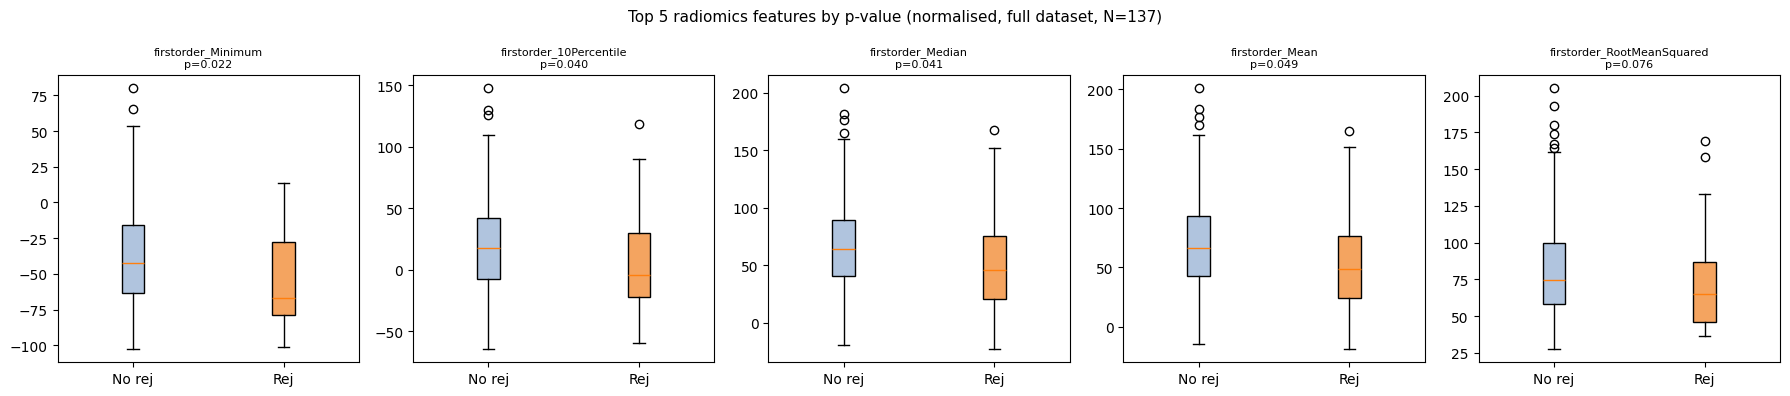

Saved to reports/14a_boxplots_top_features_normalised.png


In [9]:
top5 = results_df.head(5)["feature"].tolist()

fig, axes = plt.subplots(1, 5, figsize=(18, 4))
for i, feat in enumerate(top5):
    data_no = no_rejection[feat].values
    data_rej = rejection[feat].values
    bp = axes[i].boxplot([data_no, data_rej], labels=["No rej", "Rej"], patch_artist=True)
    bp["boxes"][0].set_facecolor("#B0C4DE")
    bp["boxes"][1].set_facecolor("#F4A460")
    short_name = feat.replace("original_", "")
    p_val = results_df[results_df["feature"] == feat]["p_value"].values[0]
    axes[i].set_title(f"{short_name}\np={p_val:.3f}", fontsize=8)

plt.suptitle("Top 5 radiomics features by p-value (normalised, full dataset, N=137)", fontsize=11)
plt.tight_layout()
plt.savefig(os.path.join("reports", "14a_boxplots_top_features_normalised.png"), dpi=150, bbox_inches="tight")
plt.show()
print("Saved to reports/14a_boxplots_top_features_normalised.png")

## Feature correlation matrix

In [10]:
corr_matrix = df[feature_cols].corr()

# count highly correlated pairs
high_corr_pairs = []
for i in range(len(feature_cols)):
    for j in range(i + 1, len(feature_cols)):
        r = corr_matrix.iloc[i, j]
        if abs(r) > 0.9:
            high_corr_pairs.append({
                "feature_1": feature_cols[i],
                "feature_2": feature_cols[j],
                "correlation": round(r, 3),
            })

print(f"Feature pairs with |r| > 0.9: {len(high_corr_pairs)}")

Feature pairs with |r| > 0.9: 316


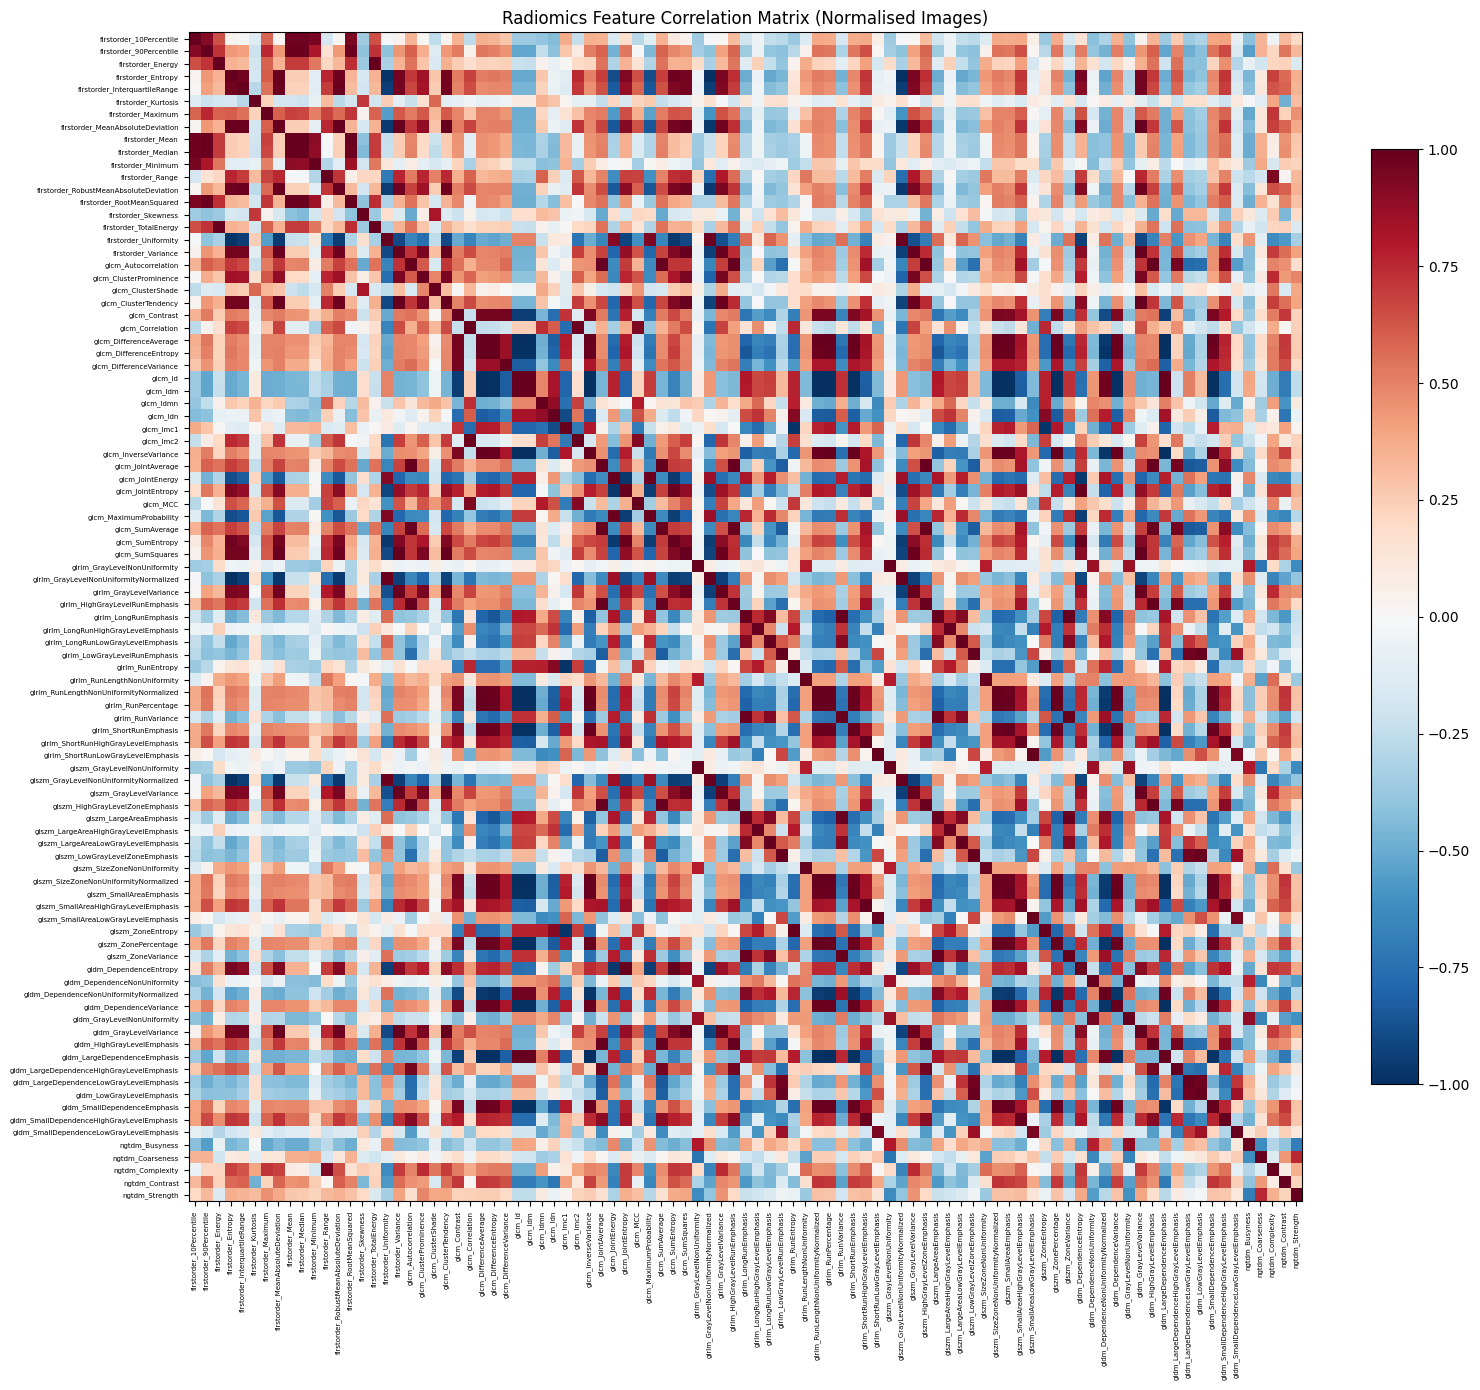

Saved to reports/14a_correlation_heatmap_radiomics_normalised.png


In [11]:
fig, ax = plt.subplots(figsize=(16, 14))
im = ax.imshow(corr_matrix.values, cmap="RdBu_r", vmin=-1, vmax=1, aspect="auto")
ax.set_xticks(range(len(feature_cols)))
ax.set_yticks(range(len(feature_cols)))
short_labels = [c.replace("original_", "") for c in feature_cols]
ax.set_xticklabels(short_labels, rotation=90, fontsize=5)
ax.set_yticklabels(short_labels, fontsize=5)
ax.set_title("Radiomics Feature Correlation Matrix (Normalised Images)")
plt.colorbar(im, ax=ax, shrink=0.8)
plt.tight_layout()
plt.savefig(os.path.join("reports", "14a_correlation_heatmap_radiomics_normalised.png"), dpi=150)
plt.show()
print("Saved to reports/14a_correlation_heatmap_radiomics_normalised.png")

In [12]:
# save
output_path = os.path.join("reports", "14a_stats_radiomics_features_normalised.csv")
results_df.to_csv(output_path, index=False)
print(f"Saved to {output_path}")

print()
print("SUMMARY")
print(f"Total radiomics features tested: {len(results_df)}")
print(f"Uncorrected p < 0.05: {len(results_df[results_df['p_value'] < 0.05])}")
print(f"FDR-corrected p < 0.05: {results_df['significant_fdr'].sum()}")

Saved to reports/14a_stats_radiomics_features_normalised.csv

SUMMARY
Total radiomics features tested: 93
Uncorrected p < 0.05: 4
FDR-corrected p < 0.05: 0
